# Analisis Clustering Polutan Udara Kec.Labang, Kab.Bangkalan
## Implementasi Python (Scikit-Learn) dan KNIME


## 1. Latar Belakang

Pencemaran udara dapat dianalisis dengan memanfaatkan data konsentrasi beberapa polutan. Pada proyek ini digunakan tiga polutan, yaitu **nitrogen dioksida (NO₂)**, **karbon monoksida (CO)**, dan **sulfur dioksida (SO₂)**.

Wilayah yang menjadi fokus pengambilan data adalah **Kecamatan Labang**. Namun, karena data seluruh mahasiswa kemudian digabungkan menjadi satu dataset untuk masing-masing polutan, proses clustering pada tahap akhir dilakukan terhadap **kumpulan wilayah/kecamatan yang terdapat pada dataset kelas**, bukan hanya terhadap Kecamatan Labang.

Tujuan analisis bukan sekadar mencari nilai polutan tertinggi atau terendah, melainkan menemukan **kelompok wilayah yang mempunyai pola karakteristik fitur yang relatif mirip**. Kemiripan tersebut dianalisis menggunakan fitur hasil ekstraksi TSFEL dan dikelompokkan dengan algoritma **K-Means**.

Secara umum, alurnya adalah:

**Data polutan → pemeriksaan & pembersihan data → penanganan missing values/outlier → ekstraksi fitur TSFEL → CSV per polutan → penggabungan data kelas → Aiven PostgreSQL → KNIME/Python → Standardisasi → PCA → K-Means → visualisasi → interpretasi.**


## 2. Tahap Persiapan Data

### 2.1 Data awal polutan

| Polutan | Nama | Gambaran umum |
|---|---|---|
| NO₂ | Nitrogen Dioxide | Berkaitan antara lain dengan proses pembakaran dan emisi kendaraan/industri |
| CO | Carbon Monoxide | Gas hasil pembakaran tidak sempurna |
| SO₂ | Sulfur Dioxide | Banyak berkaitan dengan pembakaran bahan bakar yang mengandung sulfur |

### 2.2 Pemeriksaan kualitas data

Sebelum ekstraksi fitur, data telah melalui proses pemeriksaan dan penanganan **missing values** serta **outlier**. Tahap ini penting karena nilai kosong dapat menyebabkan kegagalan perhitungan fitur, sedangkan outlier yang tidak ditangani dapat membuat statistik seperti mean, variance, kurtosis, dan fitur lainnya menjadi sangat dipengaruhi nilai ekstrem.

### 2.3 Ekstraksi fitur dengan TSFEL

Setelah data bersih, data time series diekstraksi menggunakan **TSFEL (Time Series Feature Extraction Library)**. Hasilnya bukan lagi sekadar deret nilai polutan harian, tetapi sekumpulan fitur statistik dan karakteristik sinyal yang mewakili perilaku data time series.


## 3. Penyimpanan Data di Aiven

Data CSV hasil ekstraksi fitur kemudian diunggah ke **Aiven**, yang pada proyek ini digunakan sebagai layanan database PostgreSQL.

Alasan tahap database diperlukan adalah agar data dapat dikelola secara terstruktur dan dibaca langsung oleh KNIME melalui koneksi PostgreSQL.

Konsep alurnya:

**CSV hasil TSFEL → tabel PostgreSQL di Aiven → KNIME PostgreSQL Connector → DB Table Selector → DB Reader**

Pada tahap ini, data tidak perlu dimuat secara manual ke KNIME dari file lokal apabila tabel sudah tersedia pada database.


## 4. Implementasi K-Means dengan Python (Scikit-Learn)

Untuk mengimplementasikan rekomendasi analisis, digunakan bahasa pemrograman Python dengan library **Scikit-Learn (`sklearn`)**. Library ini menyediakan implementasi yang stabil untuk standardisasi data, PCA, dan K-Means.

Sebelum K-Means final dijalankan, jumlah cluster perlu ditentukan. Salah satu pendekatan yang digunakan adalah **Elbow Method**.

### 4.1 Mengapa perlu menentukan jumlah cluster?

K-Means membutuhkan parameter `n_clusters = K`. Jika K terlalu kecil, beberapa kelompok yang sebenarnya berbeda dapat digabung. Jika K terlalu besar, satu kelompok dapat terpecah menjadi beberapa kelompok kecil.

Elbow Method membantu melihat perubahan **inertia** ketika nilai K dinaikkan.

Secara sederhana:

**Inertia = jumlah kuadrat jarak setiap data terhadap centroid cluster-nya.**

Semakin besar K, inertia cenderung semakin kecil. Titik yang dicari adalah bagian kurva ketika penurunan inertia mulai melandai sehingga penambahan cluster berikutnya memberikan pengurangan inertia yang relatif lebih kecil.

> **Catatan penting:** angka K final yang digunakan pada pekerjaan ini adalah konfigurasi yang tampak pada kode dan hasil KNIME yang diberikan, yaitu **NO₂ = 6 cluster, CO = 6 cluster, SO₂ = 6 cluster**.

In [5]:
# Import library
import pandas as pd
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Upload file CSV
uploaded = files.upload()

# Ambil nama file yang di-upload
nama_file = next(iter(uploaded))

# Baca file CSV
df = pd.read_csv(nama_file)

# Kolom identitas tidak digunakan sebagai fitur clustering
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

# Menampilkan informasi data
print("Nama file:", nama_file)
print("Ukuran data:", df.shape)
print("Jumlah fitur clustering:", fitur.shape[1])
print("\n5 data pertama:")
display(fitur.head())

Saving ekstraksi_fitur_no2.csv to ekstraksi_fitur_no2.csv
Nama file: ekstraksi_fitur_no2.csv
Ukuran data: (37, 71)
Jumlah fitur clustering: 68

5 data pertama:


,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,1.933040e-06,0.023990,7,5.310551e-09,186.075084,0.000168,0.000066,0.000059,1.543805e-05,0.000031,...,0.147818,0.336845,1.288098e-09,0.005077,0.000004,0.000043,2.147398,0.000043,1.940374e-09,0
1,3.702058e-07,0.010905,8,1.014262e-09,194.285209,0.000059,0.000030,0.000030,7.337210e-06,0.000011,...,0.147428,0.319585,1.366945e-10,0.001801,0.000002,0.000016,2.123802,0.000016,2.814972e-10,0
2,7.363589e-07,0.015059,11,2.017422e-09,166.039562,0.000086,0.000041,0.000041,-6.819737e-07,0.000018,...,0.144113,0.282633,4.347435e-10,0.002744,0.000001,0.000023,2.131037,0.000023,6.029032e-10,2
3,3.854020e-07,0.011228,6,1.055896e-09,196.838820,0.000062,0.000031,0.000029,6.818168e-06,0.000010,...,0.156054,0.275151,1.258376e-10,0.002168,0.000002,0.000013,2.154113,0.000013,1.879498e-10,0
4,1.523980e-06,0.022417,3,4.175288e-09,184.039735,0.000124,0.000061,0.000060,8.486155e-06,0.000020,...,0.154967,0.685525,7.180607e-10,0.004380,0.000003,0.000031,2.145496,0.000031,1.040073e-09,0


### 4.2 Standardisasi Fitur

Fitur hasil TSFEL dapat memiliki skala yang berbeda. Jika suatu fitur memiliki nilai numerik yang jauh lebih besar daripada fitur lainnya, fitur tersebut dapat memberikan pengaruh yang lebih dominan terhadap jarak Euclidean yang digunakan pada *K-Means*.

Oleh karena itu, digunakan metode **`StandardScaler()`**.

Transformasi dilakukan menggunakan rumus berikut:

$$z = \frac{x - \mu}{\sigma}$$

Keterangan:
* $x$ = nilai asli
* $\mu$ = rerata (*mean*) fitur
* $\sigma$ = standar deviasi
* $z$ = nilai setelah standardisasi

Hasil standardisasi membuat setiap fitur berada pada skala yang sebanding sebelum diproses oleh PCA dan *K-Means*.

In [6]:
# Standardisasi
scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)

print("Shape data setelah standardisasi:", fitur_scaled.shape)


Shape data setelah standardisasi: (37, 68)


### 4.3 PCA

**Principal Component Analysis (PCA)** digunakan untuk mentransformasikan fitur yang saling berkorelasi menjadi sejumlah komponen utama.

PCA mencari arah baru yang mempertahankan variasi data sebanyak mungkin.

Pada kode tugas digunakan:

`PCA(n_components=37)`

Jika dataset memang mempunyai **37 fitur numerik**, penggunaan 37 komponen berarti seluruh 37 komponen dipertahankan. Jadi, PCA pada tahap ini lebih tepat dipahami sebagai **transformasi ke ruang komponen utama**, bukan pengurangan jumlah dimensi dari 37 menjadi 2.

Untuk visualisasi 2 dimensi, PCA sebaiknya dibuat terpisah dengan `n_components=2`.



In [7]:
# PCA
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

print("Shape setelah PCA:", fitur_pca.shape)


Shape setelah PCA: (37, 37)


### 4.4 Elbow Method

Kode berikut mencoba beberapa nilai K, yaitu 2 sampai 10, kemudian menghitung inertia masing-masing model.

```python
K_range = range(2, 11)
```

Nilai inertia yang lebih rendah berarti data dalam cluster secara keseluruhan lebih dekat dengan centroid. Akan tetapi, inertia selalu cenderung turun ketika K bertambah, sehingga yang diperhatikan bukan sekadar nilai inertia terkecil, melainkan **bentuk kurva dan titik perubahan kemiringan (elbow)**.


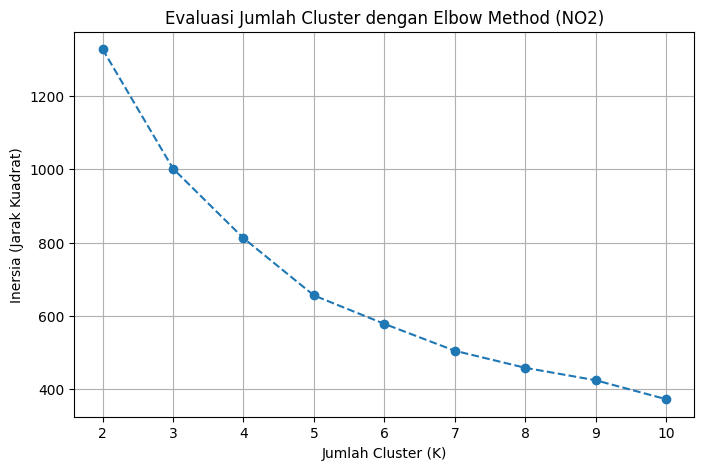

In [8]:
# Elbow Method
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method (NO2)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()


### 4.5 Kode Elbow untuk ketiga polutan

Agar proses konsisten, berikut kode yang dapat dijalankan untuk NO₂, CO, dan SO₂ sekaligus.


Saving ekstraksi_fitur_so2.csv to ekstraksi_fitur_so2.csv
Saving ekstraksi_fitur_co.csv to ekstraksi_fitur_co (1).csv
Saving ekstraksi_fitur_no2.csv to ekstraksi_fitur_no2 (4).csv
File yang berhasil di-upload:
- ekstraksi_fitur_so2.csv
- ekstraksi_fitur_co (1).csv
- ekstraksi_fitur_no2 (4).csv

File yang digunakan:
NO2 : ekstraksi_fitur_no2 (4).csv
CO  : ekstraksi_fitur_co (1).csv
SO2 : ekstraksi_fitur_so2.csv


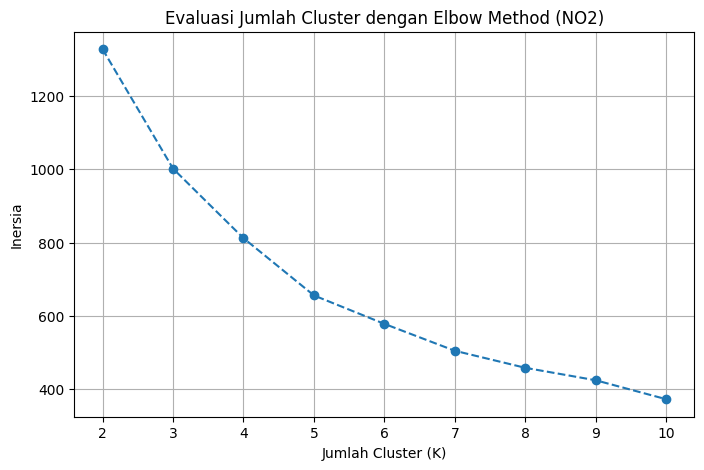

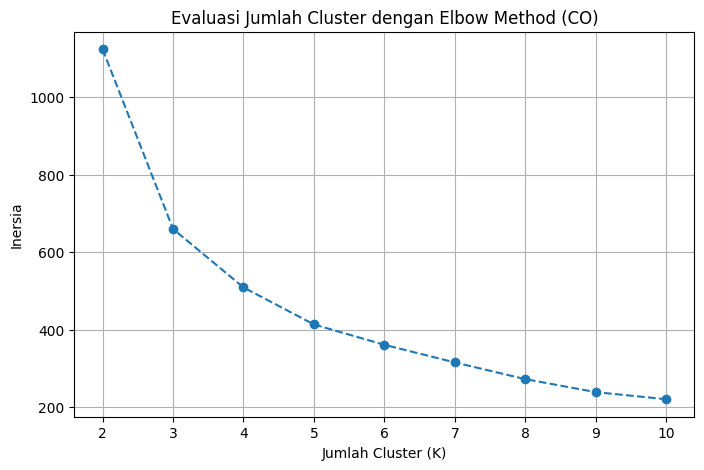

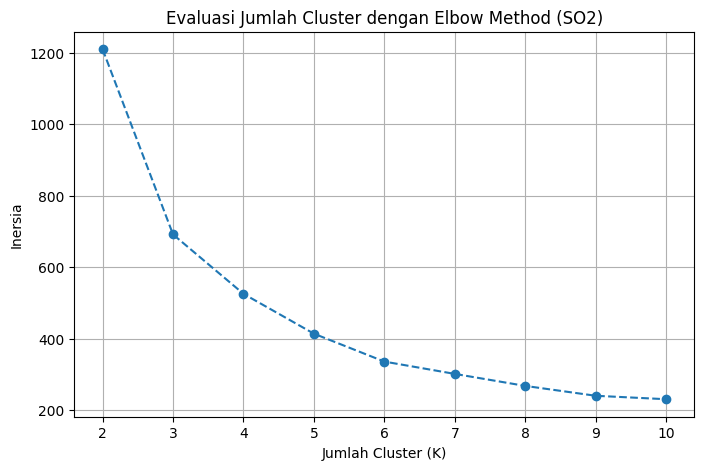

In [16]:
def elbow_analysis(path, pollutant):
    df = pd.read_csv(path)
    fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

    scaler = StandardScaler()
    fitur_scaled = scaler.fit_transform(fitur)


    fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

    inertia = []
    K_range = range(2, 11)

    for k in K_range:
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        model.fit(fitur_pca)
        inertia.append(model.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(K_range, inertia, marker='o', linestyle='--')
    plt.title(
        f'Evaluasi Jumlah Cluster dengan Elbow Method ({pollutant})'
    )
    plt.xlabel('Jumlah Cluster (K)')
    plt.ylabel('Inersia')
    plt.grid(True)
    plt.show()

    return pd.DataFrame({
        'K': list(K_range),
        'Inertia': inertia
    })


from google.colab import files

uploaded = files.upload()

print("File yang berhasil di-upload:")
for filename in uploaded.keys():
    print("-", filename)


if len(uploaded) != 3:
    raise ValueError(
        "Harap upload tepat 3 file: NO2, CO, dan SO2."
    )


path_no2 = None
path_co = None
path_so2 = None

for filename in uploaded.keys():

    nama = filename.lower()

    if 'no2' in nama:
        path_no2 = filename

    elif 'so2' in nama:
        path_so2 = filename

    elif 'co' in nama:
        path_co = filename



if path_no2 is None:
    raise ValueError("File NO2 tidak ditemukan.")

if path_co is None:
    raise ValueError("File CO tidak ditemukan.")

if path_so2 is None:
    raise ValueError("File SO2 tidak ditemukan.")


print("\nFile yang digunakan:")
print("NO2 :", path_no2)
print("CO  :", path_co)
print("SO2 :", path_so2)



elbow_no2 = elbow_analysis(
    path_no2,
    'NO2'
)


elbow_co = elbow_analysis(
    path_co,
    'CO'
)


elbow_so2 = elbow_analysis(
    path_so2,
    'SO2'
)

## 5. K-Means Final dan Profiling

Setelah jumlah cluster dipilih, model K-Means final dijalankan.

Konfigurasi yang digunakan dalam pekerjaan:
- **NO₂ → K = 6**
- **CO → K = 4**
- **SO₂ → K = 6**

K-Means bekerja dengan langkah utama:
1. Menentukan centroid awal.
2. Menghitung jarak setiap data terhadap centroid.
3. Menempatkan data pada cluster dengan jarak terdekat.
4. Menghitung ulang centroid.
5. Mengulangi proses sampai perubahan centroid/keanggotaan memenuhi kondisi berhenti.

Pada Scikit-Learn digunakan `n_init=10`, sehingga model mencoba beberapa inisialisasi centroid dan memilih hasil berdasarkan inertia terendah dari percobaan tersebut.


In [20]:
def run_kmeans(path, pollutant, k):
    df = pd.read_csv(path)

    identitas = df[['id', 'nama', 'daerah']]
    fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

    scaler = StandardScaler()
    fitur_scaled = scaler.fit_transform(fitur)

    pca = PCA(n_components=37)
    fitur_pca = pca.fit_transform(fitur_scaled)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(fitur_pca)

    df_hasil = identitas.copy()
    df_hasil['Cluster'] = clusters

    return df, df_hasil, fitur_pca, kmeans, pca

df_no2, hasil_no2, pca_no2, model_no2, pca_model_no2 = run_kmeans(
    path_no2, 'NO2', 6
)

df_co, hasil_co, pca_co, model_co, pca_model_co = run_kmeans(
    path_co, 'CO', 6
)

df_so2, hasil_so2, pca_so2, model_so2, pca_model_so2 = run_kmeans(
    path_so2, 'SO2', 6
)

print("NO2:", hasil_no2.shape)
print("CO :", hasil_co.shape)
print("SO2:", hasil_so2.shape)

NO2: (37, 4)
CO : (37, 4)
SO2: (37, 4)


## 6. Visualisasi yang Tepat untuk PCA

Jika tujuan visualisasi adalah melihat pemisahan cluster pada ruang PCA, gunakan dua komponen pertama:

- Sumbu X = PCA 1
- Sumbu Y = PCA 2
- Warna = Cluster

Ini berbeda dengan scatter plot KNIME yang diberikan pada tugas. Scatter plot KNIME tersebut menggunakan:
- sumbu X = `daerah`
- sumbu Y = `Cluster`

Jadi grafik KNIME lebih tepat dibaca sebagai **persebaran/keanggotaan cluster berdasarkan wilayah**, bukan sebagai scatter plot PCA 1 vs PCA 2.



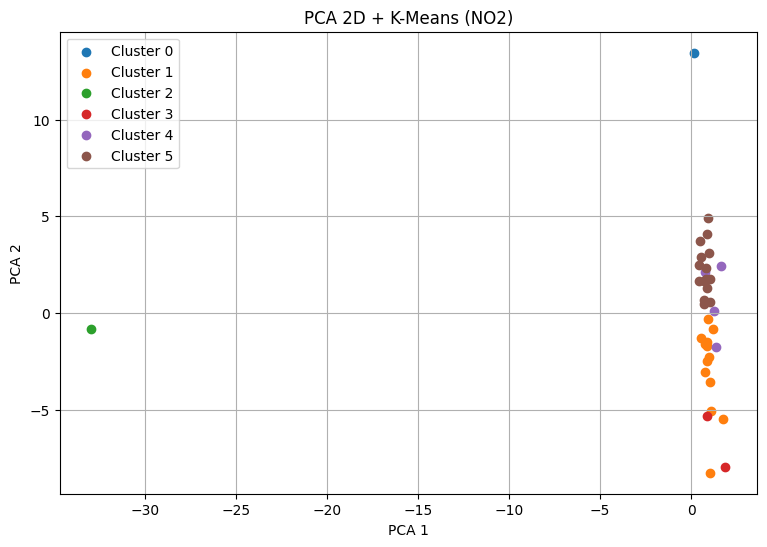

In [21]:
# Visualisasi PCA 2D untuk NO2
pca_2d = PCA(n_components=2).fit_transform(
    StandardScaler().fit_transform(
        df_no2.drop(['id', 'nama', 'daerah'], axis=1)
    )
)

plot_df = pd.DataFrame({
    'PCA1': pca_2d[:, 0],
    'PCA2': pca_2d[:, 1],
    'Cluster': hasil_no2['Cluster'].values
})

plt.figure(figsize=(9, 6))
for cluster in sorted(plot_df['Cluster'].unique()):
    subset = plot_df[plot_df['Cluster'] == cluster]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cluster}')

plt.title('PCA 2D + K-Means (NO2)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.legend()
plt.show()


## 7. Profiling Cluster Berdasarkan Daerah

Kode tugas membuat ringkasan:

`groupby(['Cluster', 'daerah']).size()`

Artinya, kita menghitung berapa data yang berasal dari suatu daerah dan masuk ke cluster tertentu.

Kemudian data diurutkan berdasarkan cluster dan jumlah data, lalu diambil tiga daerah teratas pada masing-masing cluster.

Perlu diperhatikan bahwa **cluster 0, 1, 2, dan seterusnya hanyalah label**. Label cluster tidak mempunyai arti "0 = paling rendah" atau "5 = paling tinggi". Arti cluster harus ditentukan dengan melihat karakteristik fitur/centroid masing-masing cluster.


In [22]:
def profiling(hasil, top_n=3):
    profil_daerah = (
        hasil.groupby(['Cluster', 'daerah'])
        .size()
        .reset_index(name='Jumlah')
    )

    top_per_cluster = (
        profil_daerah
        .sort_values(['Cluster', 'Jumlah'], ascending=[True, False])
        .groupby('Cluster')
        .head(top_n)
    )

    return profil_daerah, top_per_cluster

profil_no2, top_no2 = profiling(hasil_no2)
profil_co, top_co = profiling(hasil_co)
profil_so2, top_so2 = profiling(hasil_so2)

print("Top 3 daerah per cluster - NO2")
display(top_no2)

print("Top 3 daerah per cluster - CO")
display(top_co)

print("Top 3 daerah per cluster - SO2")
display(top_so2)


Top 3 daerah per cluster - NO2


,Cluster,daerah,Jumlah
0,0,"Warudoyong, Kota Sukabumi",1
1,1,"Bangkalan Kota,Bangkalan",1
2,1,"Gresik Kota, Gresik",1
3,1,"Kamal, Bangkalan",1
14,2,"Kamal, Banyuajuh",1
15,3,"Cerme, Gresik",1
16,3,"Kec. Kalianget, Sumenep",1
17,4,"Kota Sumenep, Sumenep",1
18,4,"Labang, Bangkalan",1
19,4,"Sreseh, Sampang",1


Top 3 daerah per cluster - CO


,Cluster,daerah,Jumlah
0,0,"Asemrowo, Surabaya",1
1,0,"Bandung, Jogoroto, Jombang",1
2,0,"Kecamatan Bangkalan,Bangkalan",1
10,1,"Kamal, Banyuajuh",1
11,2,"Kamal, Bangkalan",1
12,3,"Banyu Ajuh, Perumnas, Kamal",1
13,3,"Dukun, Gresik",1
14,3,"Gresik Kota, Gresik",1
28,4,Baron Nganjuk,1
29,4,"Kerek, Tuban",1


Top 3 daerah per cluster - SO2


,Cluster,daerah,Jumlah
0,0,"Kec. Bangkalan, Kab. Bangkalan",1
1,0,"Tanah Merah, Bangkalan",1
2,0,"Warudoyong, Kota Sukabumi",1
3,1,"Asemrowo, Surabaya",1
4,1,"Bandung, Jogoroto, Jombang",1
5,1,Baron Nganjuk,1
17,2,"Kamal, Banyuajuh",1
18,3,"Kamal, Bangkalan",1
19,4,"Banyu Ajuh, Perumnas, Kamal",1
20,4,"Cerme, Gresik",1


# 8. Implementasi pada KNIME

Berdasarkan workflow KNIME yang diberikan, terdapat tiga workflow yang pada dasarnya mempunyai struktur sama. Perbedaannya adalah tabel/polutan yang dianalisis dan jumlah cluster final.

### Urutan node

**PostgreSQL Connector → DB Table Selector → DB Reader → PCA → k-Means → Scatter Plot**

Workflow:
- NO₂ menggunakan tabel/data NO₂ dan K = 6.
- CO menggunakan tabel/data CO dan K = 6.
- SO₂ menggunakan tabel/data SO₂ dan K = 6.



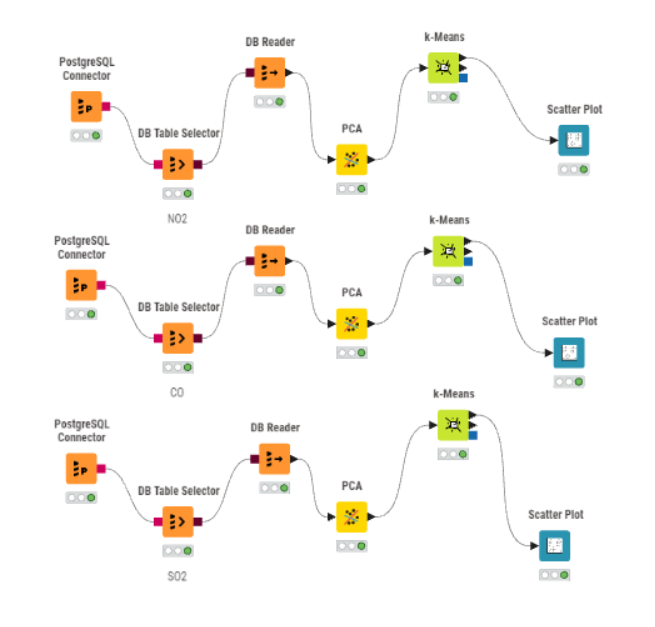

## 8.1 PostgreSQL Connector

Node **PostgreSQL Connector** digunakan untuk membuat koneksi dari KNIME menuju database PostgreSQL yang berada pada Aiven.

Informasi yang biasanya diperlukan:
- host/server,
- port,
- database,
- username,
- password,
- SSL/secure connection sesuai konfigurasi Aiven.

Fungsi node ini adalah menyediakan koneksi database agar node berikutnya dapat mengambil data dari PostgreSQL.

### Mengapa Aiven?

Aiven berperan sebagai tempat penyimpanan data PostgreSQL yang dapat diakses dari lingkungan analisis. Dengan demikian, dataset hasil penggabungan tidak harus berada hanya di komputer lokal.


## 8.2 DB Table Selector

Node **DB Table Selector** digunakan untuk memilih tabel yang akan dianalisis.

Pada gambar workflow terlihat:
- workflow pertama memilih tabel **NO2**,
- workflow kedua memilih tabel **CO**,
- workflow ketiga memilih tabel **SO2**.

Tahap ini memastikan KNIME mengambil dataset polutan yang sesuai.


## 8.3 DB Reader

Node **DB Reader** digunakan untuk membaca isi tabel yang telah dipilih sehingga data dapat diteruskan ke proses analitik KNIME.

Secara konseptual:

**Database table → DB Reader → data table di KNIME**

Setelah data berhasil dibaca, data dapat diproses oleh node machine learning seperti PCA dan K-Means.


## 8.4 PCA pada KNIME

Node **PCA (Principal Component Analysis)** melakukan transformasi data berdimensi tinggi ke komponen utama.

Tujuannya:
- mengurangi kompleksitas representasi,
- menangkap variasi utama data,
- membantu proses clustering,
- dan dapat membantu visualisasi.

PCA tidak berarti membuang informasi secara sembarangan. Komponen utama disusun berdasarkan banyaknya variasi data yang dapat dijelaskan.

**Catatan:** jika jumlah komponen yang dipertahankan sama dengan jumlah fitur awal, maka PCA tidak benar-benar mengurangi jumlah dimensi. Untuk visualisasi 2D, cukup menggunakan dua komponen utama.


## 8.5 k-Means pada KNIME

Node **k-Means** melakukan pengelompokan data berdasarkan kemiripan.

Konfigurasi hasil pekerjaan:
| Polutan | Jumlah Cluster |
|---|---:|
| NO₂ | 6 |
| CO | 6 |
| SO₂ | 6 |

Output k-Means memberikan label cluster untuk setiap baris data.


## 8.6 Scatter Plot pada KNIME

Node **Scatter Plot** digunakan untuk menampilkan distribusi hasil clustering.

Pada hasil yang diberikan,:
- sumbu X menunjukkan `daerah`,
- sumbu Y menunjukkan `Cluster`,
- setiap titik mewakili data/wilayah yang masuk ke cluster tertentu.

Karena `daerah` merupakan variabel kategorikal, grafik ini terutama digunakan untuk melihat **wilayah mana yang masuk ke cluster mana**.

Grafik ini bukan bukti langsung bahwa cluster terpisah dengan baik dalam ruang PCA. Untuk menilai pemisahan matematis, gunakan PCA 2D atau metrik seperti silhouette score.


# 9. Hasil Clustering NO₂

Jumlah cluster yang digunakan pada hasil NO₂ adalah **6 cluster**: `cluster_0` sampai `cluster_5`.

Grafik yang diberikan memperlihatkan bahwa data wilayah tersebar pada keenam kelompok. Terlihat pula bahwa jumlah titik pada setiap cluster tidak sama. Salah satu cluster terlihat memiliki jumlah anggota lebih banyak dibanding beberapa cluster lainnya.

Hal ini menunjukkan bahwa karakteristik fitur NO₂ tidak terbagi secara merata ke dalam enam kelompok. Ada kelompok yang mempunyai banyak wilayah dengan karakteristik yang relatif mirip, sementara kelompok lain berisi lebih sedikit wilayah.

### Cara membaca hasil

- Titik pada `cluster_0` berarti wilayah tersebut memperoleh label cluster 0.
- Titik pada `cluster_4` berarti wilayah tersebut memperoleh label cluster 4.
- Demikian seterusnya.
- Label tidak menunjukkan tingkat polusi secara langsung.

Interpretasi "cluster dengan NO₂ tinggi" harus dilakukan setelah membandingkan nilai fitur atau centroid antar-cluster.


### Scatter Plot hasil NO₂
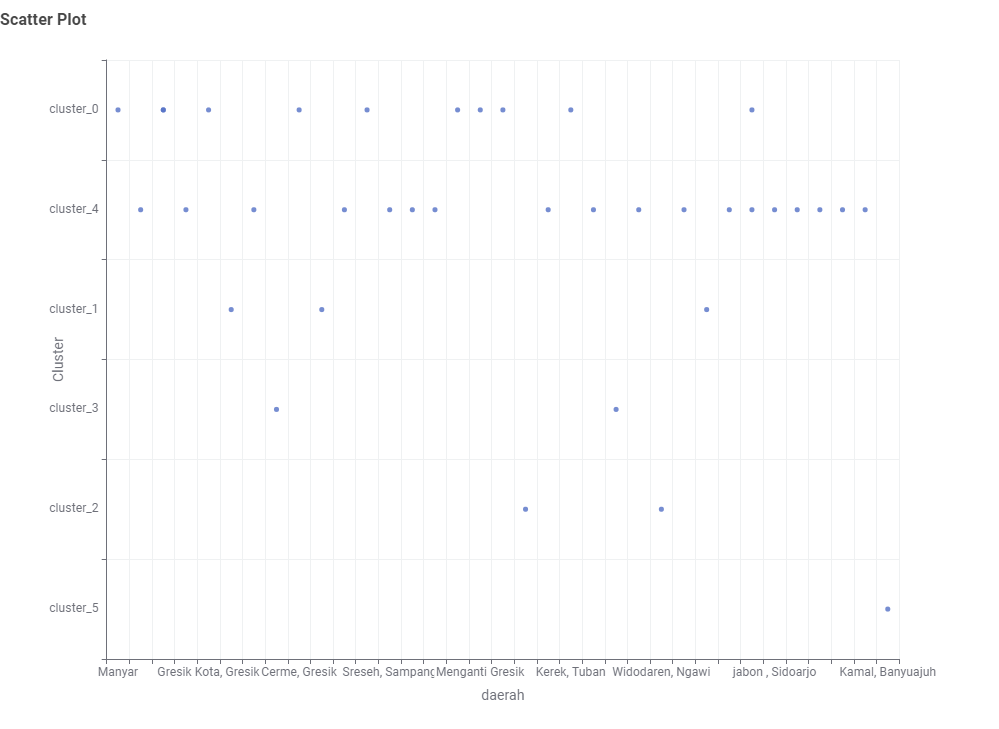

### Pembahasan NO₂

Pada grafik NO₂ terlihat bahwa terdapat beberapa kelompok dengan jumlah anggota berbeda. `cluster_4` tampak mempunyai banyak titik yang tersebar di sejumlah wilayah, sedangkan beberapa cluster lain mempunyai anggota lebih sedikit.

Temuan tersebut dapat digunakan sebagai dasar untuk melakukan **profiling lanjutan**. Misalnya, jika ingin mengetahui karakteristik cluster 4, kita harus menghitung rata-rata/median fitur TSFEL atau centroid K-Means untuk cluster 4, kemudian membandingkannya dengan cluster lain.


# 10. Hasil Clustering CO

Untuk CO digunakan **6 cluster**, yaitu `cluster_0` sampai `cluster_3`.

Dibandingkan NO₂ dan SO₂, jumlah cluster CO lebih sedikit. Artinya, pada konfigurasi analisis yang digunakan, data CO dikelompokkan menjadi empat kelompok karakteristik.

Pada scatter plot terlihat ada cluster yang memiliki banyak anggota dan ada cluster yang hanya memiliki sedikit anggota. Ketidakseimbangan jumlah anggota merupakan hal yang mungkin terjadi pada K-Means dan tidak otomatis menunjukkan kesalahan model.


### Scatter Plot hasil CO
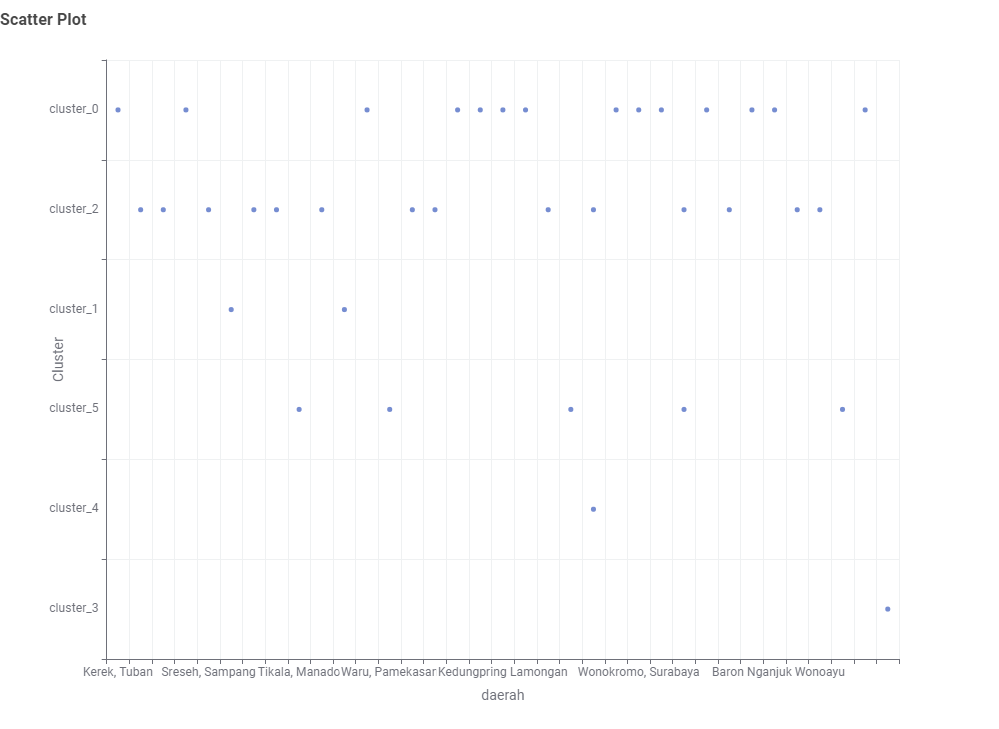

### Pembahasan CO

Dari grafik, `cluster_0` dan `cluster_2` tampak mempunyai anggota yang relatif lebih banyak dibanding kelompok lain, sementara beberapa cluster mempunyai anggota lebih sedikit.

Pola ini menunjukkan bahwa terdapat kelompok karakteristik CO yang lebih umum dan beberapa kelompok yang lebih spesifik.

Namun, untuk menyatakan bahwa suatu cluster memiliki kadar CO lebih tinggi/rendah, diperlukan profiling terhadap:
- fitur statistik TSFEL,
- centroid,
- atau nilai konsentrasi CO yang telah dibersihkan.

Dengan demikian, hasil yang aman dari scatter plot adalah **perbedaan pola/kelompok**, bukan peringkat tingkat pencemaran.


# 11. Hasil Clustering SO₂

Untuk SO₂ digunakan **6 cluster**, yaitu `cluster_0` sampai `cluster_5`.

Grafik memperlihatkan beberapa cluster mempunyai anggota yang cukup banyak, sementara cluster lainnya mempunyai anggota yang jauh lebih sedikit. Pola tersebut menunjukkan bahwa karakteristik fitur SO₂ pada dataset tidak tersebar secara seragam.


### Scatter Plot hasil SO₂
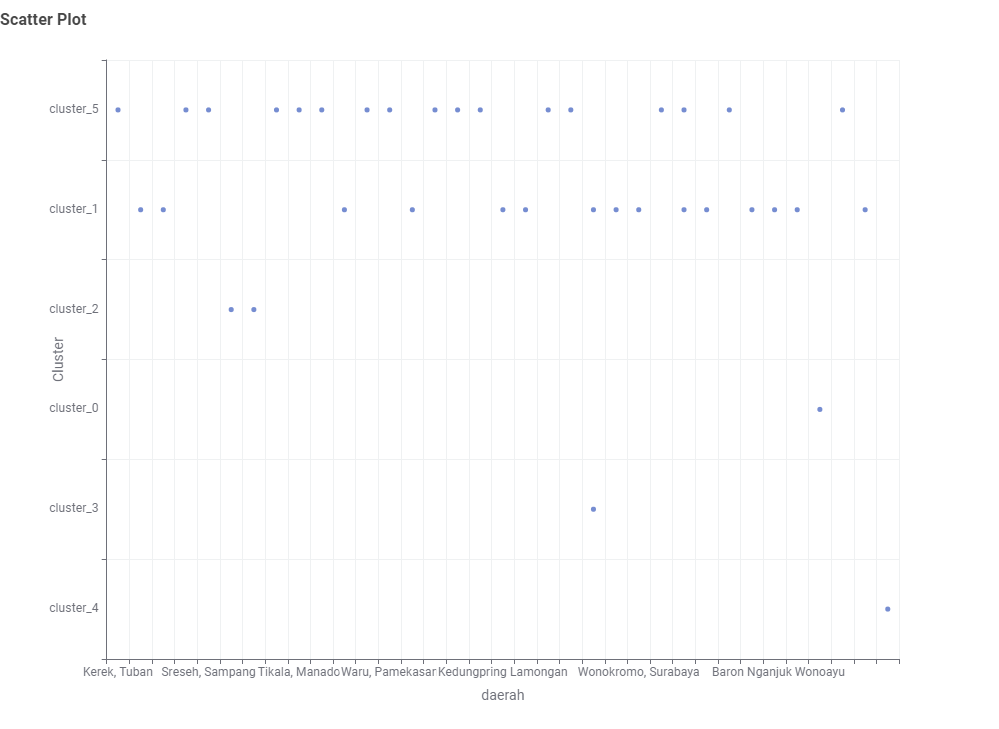

### Pembahasan SO₂

Pada hasil SO₂, `cluster_5` dan `cluster_1` terlihat mempunyai banyak titik, sedangkan beberapa cluster lain lebih sedikit.

Sama seperti NO₂ dan CO, nomor cluster hanya merupakan identitas kelompok. Untuk mengetahui karakteristik setiap kelompok, lakukan profiling menggunakan centroid atau ringkasan fitur.

Jika misalnya centroid sebuah cluster mempunyai nilai rata-rata fitur tertentu lebih tinggi daripada cluster lain, fitur tersebut dapat digunakan untuk menjelaskan ciri cluster tersebut. Interpretasi harus dilakukan pada fitur yang memang memiliki makna substantif, bukan berdasarkan nomor cluster.


# 12. Perbandingan Hasil Tiga Polutan

| Aspek | NO₂ | CO | SO₂ |
|---|---:|---:|---:|
| Jumlah cluster final | 6 | 6 | 6 |
| Algoritma | K-Means | K-Means | K-Means |
| Standardisasi | Ya | Ya | Ya |
| PCA | Ya | Ya | Ya |
| Sumber data | CSV/PostgreSQL Aiven | CSV/PostgreSQL Aiven | CSV/PostgreSQL Aiven |
| Output utama | Label cluster per wilayah | Label cluster per wilayah | Label cluster per wilayah |

### Makna perbandingan

Ketiga polutan menghasilkan struktur cluster yang berbeda. Hal ini wajar karena karakteristik time series NO₂, CO, dan SO₂ tidak harus sama.

Perbedaan jumlah cluster yang digunakan juga menunjukkan bahwa pola data untuk masing-masing polutan dianalisis sebagai dataset terpisah.

**Jangan menyamakan `cluster_0` NO₂ dengan `cluster_0` CO atau `cluster_0` SO₂.** Nomor tersebut dibuat secara independen oleh masing-masing proses K-Means.


# 13. Evaluasi Tambahan yang Disarankan

Selain Elbow Method, kualitas clustering dapat diperiksa dengan **Silhouette Score**.

Secara umum:
- mendekati **1** → anggota cluster cenderung dekat dengan cluster sendiri dan jauh dari cluster lain,
- sekitar **0** → terdapat kemungkinan overlap,
- nilai negatif → beberapa data dapat lebih dekat ke cluster lain.

Silhouette Score sebaiknya digunakan sebagai **informasi pendukung**, bukan satu-satunya dasar keputusan.



# 14. Kesimpulan

Berdasarkan keseluruhan proses, proyek ini menerapkan alur analisis data time series secara bertahap, mulai dari persiapan data polutan hingga pengelompokan wilayah menggunakan machine learning.

1. **Data polutan NO₂, CO, dan SO₂** dipersiapkan terlebih dahulu dengan pemeriksaan kualitas data serta penanganan missing values dan outlier.
2. Data time series kemudian diekstraksi menggunakan **TSFEL** sehingga setiap wilayah direpresentasikan oleh sekumpulan fitur numerik.
3. Hasil ekstraksi dari seluruh mahasiswa digabungkan menjadi dataset kelas untuk masing-masing polutan.
4. Dataset disimpan pada **PostgreSQL di Aiven** sehingga dapat diakses melalui koneksi database.
5. Pada KNIME digunakan alur **PostgreSQL Connector → DB Table Selector → DB Reader → PCA → k-Means → Scatter Plot**.
6. Sebelum implementasi final, **Elbow Method** digunakan untuk mengevaluasi kandidat jumlah cluster.
7. Konfigurasi clustering yang digunakan pada hasil yang diberikan adalah **6 cluster untuk NO₂, 6 cluster untuk CO, dan 6 cluster untuk SO₂**.
8. Hasil scatter plot menunjukkan bahwa wilayah-wilayah dalam dataset tersebar ke beberapa cluster dengan jumlah anggota yang tidak selalu sama.
9. Nomor cluster tidak menunjukkan tingkat pencemaran. Makna setiap cluster harus diperoleh melalui **profiling fitur, centroid, nilai konsentrasi, dan metrik evaluasi**.
10. Untuk pengembangan analisis, **Silhouette Score** dapat digunakan sebagai evaluasi tambahan dan PCA 2D dapat digunakan untuk melihat pemisahan cluster secara visual.

Secara keseluruhan, proyek ini menunjukkan penerapan **unsupervised machine learning** untuk menemukan pola kemiripan karakteristik polutan antarwilayah. Hasil clustering dapat menjadi dasar analisis lanjutan untuk memahami kelompok wilayah yang mempunyai karakteristik time series polutan yang serupa.
